# 📊 Data Storytelling & Statistical Validation

## Adidas Sales Dataset Analysis

### Objective
The objective of this project is to analyze Adidas sales data, validate business insights statistically, and transform analytical findings into meaningful business stories.

## 📌 Import Required Libraries

In this step, we import all required libraries for:
- Data analysis
- Data visualization
- Statistical testing

In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

sns.set(style='whitegrid')

## 📌 Load Dataset

The Adidas sales dataset is loaded into a Pandas DataFrame for analysis.

In [14]:
df = pd.read_csv("../data/adidas_sales.csv")

df.head()

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,in-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,in-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,in-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,in-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,in-store


## 📌 Dataset Understanding

In this step, we analyze:
- Data types
- Missing values
- Dataset dimensions
- Statistical summary

In [15]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (9648, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        0 non-null      float64
 1   Retailer          9648 non-null   object 
 2   Retailer ID       9648 non-null   int64  
 3   Invoice Date      9648 non-null   object 
 4   Region            9648 non-null   object 
 5   State             9648 non-null   object 
 6   City              9648 non-null   object 
 7   Product           9648 non-null   object 
 8   Price per Unit    9648 non-null   float64
 9   Units Sold        9648 non-null   int64  
 10  Total Sales       9648 non-null   float64
 11  Operating Profit  9648 non-null   float64
 12  Operating Margin  9648 non-null   float64
 13  Sales Method      9648 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 1.0+ MB


In [16]:
df.describe()   

,Unnamed: 0,Retailer ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,0.0,9.648000e+03,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,NaN,1.173850e+06,45.216625,256.930037,93273.437500,34425.244761,0.422991
std,NaN,2.636038e+04,14.705397,214.252030,141916.016727,54193.113713,0.097197
min,NaN,1.128299e+06,7.000000,0.000000,0.000000,0.000000,0.100000
25%,NaN,1.185732e+06,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,NaN,1.185732e+06,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,NaN,1.185732e+06,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,NaN,1.197831e+06,110.000000,1275.000000,825000.000000,390000.000000,0.800000


In [17]:
df.isnull().sum()

Unnamed: 0          9648
Retailer               0
Retailer ID            0
Invoice Date           0
Region                 0
State                  0
City                   0
Product                0
Price per Unit         0
Units Sold             0
Total Sales            0
Operating Profit       0
Operating Margin       0
Sales Method           0
dtype: int64

# 📌 Business Storytelling

The Adidas sales dataset provides valuable insights into:
- Regional sales performance
- Product demand
- Profitability trends
- Customer purchasing behavior

The goal is to identify key business drivers and provide actionable recommendations.

# 📌 Key Performance Indicators (KPIs)

We calculate important KPIs to evaluate overall business performance.

In [18]:
total_sales = df['Total Sales'].sum()

total_profit = df['Operating Profit'].sum()

total_units = df['Units Sold'].sum()

avg_margin = df['Operating Margin'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Units Sold:", total_units)
print("Average Operating Margin:", avg_margin)

Total Sales: 899902125.0
Total Profit: 332134761.45000005
Units Sold: 2478861
Average Operating Margin: 0.42299129353233833


## 📌 KPI Visualization

This chart provides a quick overview of business performance metrics.

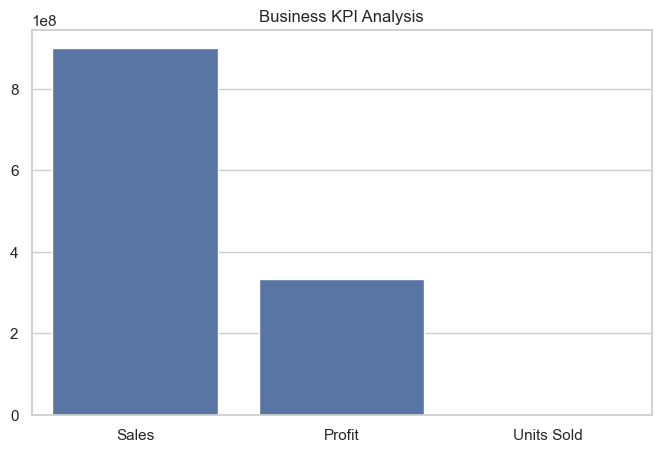

In [19]:
kpis = ['Sales', 'Profit', 'Units Sold']

values = [total_sales, total_profit, total_units]

plt.figure(figsize=(8,5))

sns.barplot(x=kpis, y=values)

plt.title("Business KPI Analysis")

plt.show()

# 📌 Regional Sales Analysis

This analysis identifies which regions contribute the most revenue.

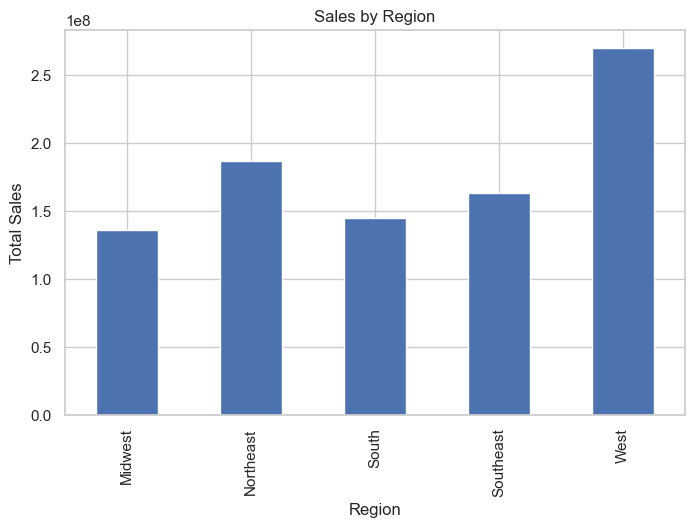

In [20]:
region_sales = df.groupby('Region')['Total Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")

plt.ylabel("Total Sales")

plt.show()

# 📌 Product Performance Analysis

This analysis helps identify the highest-performing Adidas products.

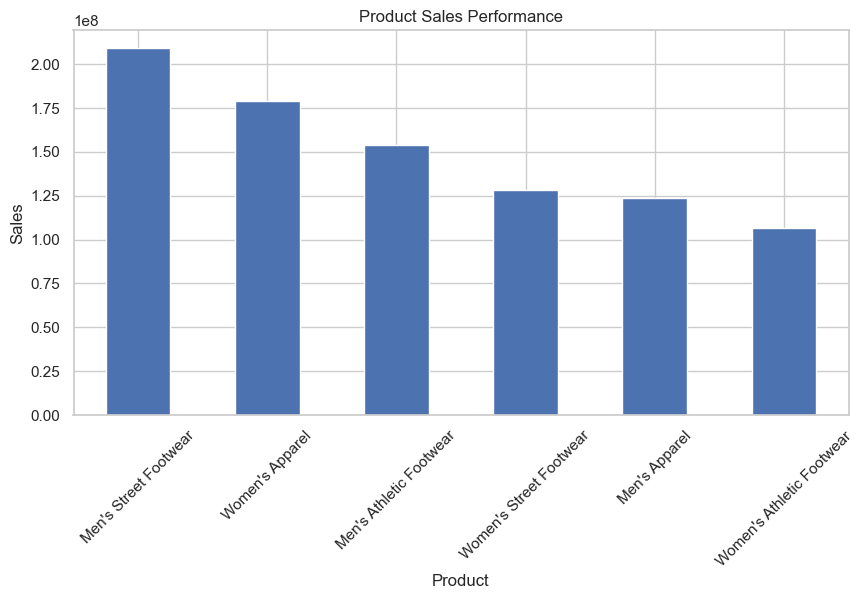

In [21]:
product_sales = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

product_sales.plot(kind='bar')

plt.title("Product Sales Performance")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

# 📌 Monthly Sales Trend Analysis

This analysis identifies seasonal trends and sales growth patterns.

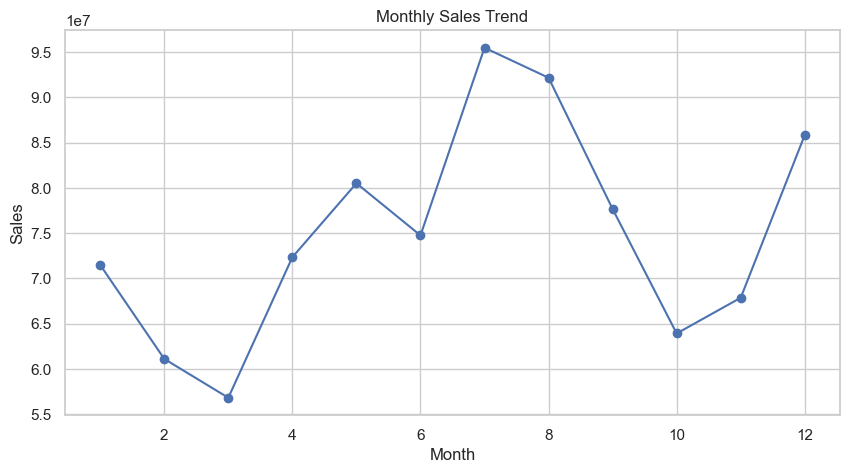

In [22]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

df['Month'] = df['Invoice Date'].dt.month

monthly_sales = df.groupby('Month')['Total Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

# 📌 Profitability Analysis

This analysis examines how profit varies across regions.

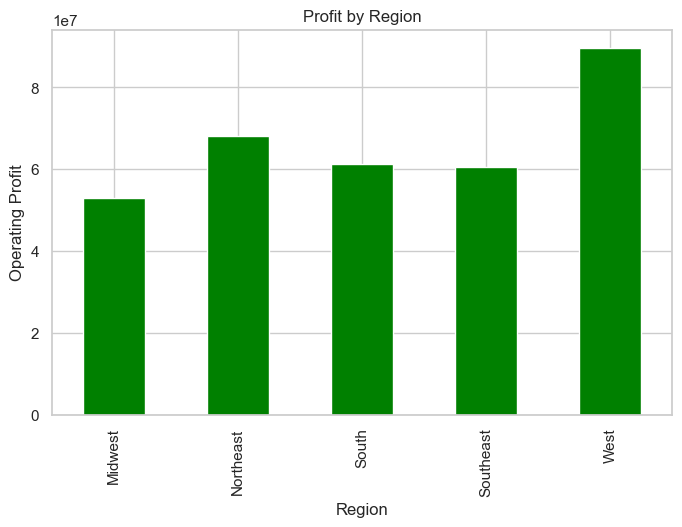

In [23]:
profit_region = df.groupby('Region')['Operating Profit'].sum()

plt.figure(figsize=(8,5))

profit_region.plot(kind='bar', color='green')

plt.title("Profit by Region")

plt.ylabel("Operating Profit")

plt.show()

# 📌 Statistical Validation

Statistical testing helps validate whether business findings are statistically significant.

Tests Performed:
- T-Test
- Chi-Square Test

## 📌 T-Test

Business Question:
Do West and Northeast regions have significantly different sales performance?

In [24]:
west_sales = df[df['Region'] == 'West']['Total Sales']

northeast_sales = df[df['Region'] == 'Northeast']['Total Sales']

t_stat, p_value = ttest_ind(west_sales, northeast_sales)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 7.761202284383056
P-Value: 1.0200953767467657e-14


## 📌 Interpretation

If the p-value is less than 0.05, the sales difference between the two regions is statistically significant.

## 📌 Chi-Square Test

Business Question:
Is there a relationship between Region and Product preference?

In [25]:
contingency_table = pd.crosstab(df['Region'], df['Product'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)

print("P-Value:", p)

Chi-Square Statistic: 0.029265482791740505
P-Value: 1.0


## 📌 Interpretation

If the p-value is below 0.05, there is a statistically significant relationship between region and product preference.

# 📌 Business Recommendations

Based on the analysis:

- Focus more on high-performing footwear products
- Strengthen operations in profitable regions
- Improve seasonal marketing campaigns
- Increase retailer partnerships
- Use analytics-driven strategies for growth

# 📌 Conclusion

This project successfully combined:
- Data analysis
- Visualization
- Statistical validation
- Business storytelling

to derive meaningful business insights from Adidas sales data.